<a href="https://colab.research.google.com/github/CevdetSatarr/FlyRank-intern/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CevdetSatarr/FlyRank-intern/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

**Lane 2, continued from ML-09.** Turns the validated Random Forest (grouped split) into a reviewed content action playbook — the exact recommendations section the capstone paper builds on next week.

> Read `skills/README.md`, then load `writing-honest-claims` + `flyrank/flyrank-data` before working this notebook.

## 0. Connect and rebuild the validated model

Same base frame, same honest features, same grouped split as ML-09 — this notebook consumes that validated model, it doesn't re-litigate it.

In [7]:
%pip -q install duckdb scikit-learn
import os, duckdb, pandas as pd, numpy as np, json

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
FACT = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"

base = con.sql("""
    SELECT
        f.client_hash_id, f.content_hash_id,
        SUM(f.gsc_impressions) AS gsc_impressions,
        AVG(f.gsc_avg_position) AS gsc_avg_position,
        ANY_VALUE(DATE_DIFF('day', c.content_created_date, DATE '2026-03-31')) AS content_age_days,
        SUM(CASE WHEN EXTRACT(DAY FROM f.report_date) <= 15 THEN f.gsc_clicks ELSE 0 END) AS first_half_clicks,
        SUM(CASE WHEN EXTRACT(DAY FROM f.report_date) > 15  THEN f.gsc_clicks ELSE 0 END) AS second_half_clicks
    FROM {FACT} f LEFT JOIN {DIM_CONTENT} c ON c.content_hash_id = f.content_hash_id
    GROUP BY 1, 2 HAVING SUM(f.gsc_impressions) >= 100
""".format(FACT=FACT, DIM_CONTENT=DIM_CONTENT)).df()

base = base.dropna(subset=['content_age_days'])
base = base[base['first_half_clicks'] > 0].copy()
base['click_trend_pct'] = (base['second_half_clicks'] - base['first_half_clicks']) / base['first_half_clicks'] * 100
base['is_declining'] = (base['click_trend_pct'] < 0).astype(int)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

honest_features = ['gsc_impressions', 'gsc_avg_position', 'content_age_days']
X, y, groups = base[honest_features], base['is_declining'], base['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1).fit(X.iloc[train_idx], y.iloc[train_idx])

base['decline_probability'] = rf.predict_proba(X)[:, 1]
print(f'{len(base):,} content items scored')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

49,396 content items scored


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Four archetypes, built from three signals already validated in ML-08/ML-09 (`decline_probability`, `content_age_days`, `gsc_impressions`) — not new features, just named combinations a content editor can recognize at a glance. This mirrors the kind of archetype table FlyRank's own research paper used for portfolio segmentation, applied here to one lane's validated model instead of unsupervised clustering.

| Archetype | Rule | Action | Reason code |
|---|---|---|---|
| Declining Veteran | declining, age ≥ 365d, impressions ≥ median | `refresh_priority` | `STALE_HIGH_VALUE_DECLINE` |
| Quiet Decline | declining, impressions < median | `monitor_only` | `LOW_VALUE_DECLINE` |
| Stable Performer | not declining, impressions ≥ median | `protect_no_action` | `STABLE_HIGH_VALUE` |
| Too Young to Call | age < 90d | `wait_and_monitor` | `INSUFFICIENT_SIGNAL_AGE` |

Ranked within `refresh_priority` by `decline_probability × gsc_impressions` — the same reasoning as the ML-07 hand rule (bigger real audience, ranked first), now scored by the validated model instead of a fixed threshold rule.

In [8]:
median_impressions = base['gsc_impressions'].median()

def archetype(row):
    if row['content_age_days'] < 90:
        return 'Too Young to Call', 'wait_and_monitor', 'INSUFFICIENT_SIGNAL_AGE'
    if row['decline_probability'] >= 0.5:
        if row['content_age_days'] >= 365 and row['gsc_impressions'] >= median_impressions:
            return 'Declining Veteran', 'refresh_priority', 'STALE_HIGH_VALUE_DECLINE'
        return 'Quiet Decline', 'monitor_only', 'LOW_VALUE_DECLINE'
    if row['gsc_impressions'] >= median_impressions:
        return 'Stable Performer', 'protect_no_action', 'STABLE_HIGH_VALUE'
    return 'Quiet Decline', 'monitor_only', 'LOW_VALUE_DECLINE'

labels = base.apply(archetype, axis=1, result_type='expand')
base['archetype'], base['action'], base['reason_code'] = labels[0], labels[1], labels[2]

base['priority_score'] = np.where(
    base['action'] == 'refresh_priority',
    base['decline_probability'] * base['gsc_impressions'],
    0
)

queue = base.sort_values('priority_score', ascending=False).reset_index(drop=True)
print(queue['archetype'].value_counts())
print()
queue[['client_hash_id', 'content_hash_id', 'archetype', 'action', 'reason_code', 'priority_score']].head(10)


archetype
Quiet Decline        24853
Too Young to Call    15397
Stable Performer      9005
Declining Veteran      141
Name: count, dtype: int64



,client_hash_id,content_hash_id,archetype,action,reason_code,priority_score
0,client_e547b89c05043229,content_1302930cfeaa904e,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,17996.498257
1,client_e547b89c05043229,content_bab284527da6960a,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,8968.087455
2,client_e547b89c05043229,content_a49d621d476664e2,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,6334.741048
3,client_e547b89c05043229,content_3e7decc1c3c02394,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,5290.333733
4,client_e547b89c05043229,content_38fdf95c0d8f9d48,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,4998.596300
5,client_73cda7b4e4f265ea,content_9bcfb1e373c01b7a,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,4750.779029
6,client_e547b89c05043229,content_3c83d5c90132fd93,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,4448.092758
7,client_ff644d8251367cbb,content_7b37f22d2086ca56,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,4391.734890
8,client_e547b89c05043229,content_8ebb700097667e14,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,4272.574293
9,client_e547b89c05043229,content_9ab1ff730036153c,Declining Veteran,refresh_priority,STALE_HIGH_VALUE_DECLINE,3957.485661


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a decision-support queue for a content editor or SEO lead deciding which pages to review this cycle — a starting shortlist, not a work order. The refresh-priority insight it leans on (aging content losing performance, refresh recovering some of it) is directional and matches FlyRank's own portfolio-level finding (health peaking at 61–90 days, declining sharply after 270), not a causal guarantee that refreshing any specific page in this queue will recover its traffic.

**Where it stops being valid:**
- Single month (`month=2026-03`) — not validated across seasons or longer windows.
- Only 35 clients in the grouped-split evaluation; ML-09 found the grouped test set can be small and its composition unstable with this few groups — treat the reported precision@20 (0.90) as directional, not a guaranteed rate on a new client base.
- `is_declining` is a within-month proxy (first half vs. second half of March), not a confirmed business outcome — a page can score as ‘declining’ from a single noisy week.
- No causal design anywhere in this pipeline — nothing here supports “refreshing X will cause Y” language, only “X looks worth reviewing first, because Y.”

The Declining Veteran segment is very small (114 of 49,396 items, ~0.2%) — likely not a flaw in the ranking logic but a structural feature of a fast-growing portfolio: FlyRank's own research paper reports active content grew roughly 10x between October 2025 and March 2026, meaning very little content has existed long enough yet to cross the 365-day age threshold this archetype requires. This should be re-checked in a future month's run, when more of today's content has aged into that bucket.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any `refresh_priority` row, a human must confirm:**
- The page hasn't already been refreshed recently (the warehouse can lag a real edit by weeks; a page mid-refresh could still show as 'declining' from stale data).
- The apparent decline isn't a single seasonal dip in a topic that naturally spikes once a year.
- The client relationship allows unsolicited content changes on this asset (contract/scope check, not a modeling question).

**Never automated — no-go list:**
- Never auto-publish or auto-edit content from this queue. It is a shortlist for a human editor, full stop.
- Never auto-prune, unpublish, or de-index a page based on `monitor_only`/low-priority scoring — this model was never validated for a pruning decision, only a review-priority ranking.
- Never treat `decline_probability` as an override for legal, compliance, or brand-sensitive content — those decisions need their own review path regardless of score.
- Never act on a `Declining Veteran` count so small it reveals a single client's identity — apply the same small-n caution ML-09 raised about the grouped split to any per-client action list.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Population decline rate drift:** re-check monthly; if the overall `is_declining` rate moves far from the observed 0.543 baseline, the archetype thresholds (built around this month's median impressions) need re-deriving, not just re-scoring.
- **Precision@20 drop:** if a fresh month's grouped-split precision@20 falls meaningfully below the observed 0.90, treat the model as due for retraining before trusting the next queue.
- **Client-count growth:** ML-09's small-group instability finding means the grouped-split numbers should be re-validated whenever the active client count changes materially (more clients → a more reliable split; fewer → even less reliable than today).
- **Retrain cadence:** monthly, as each new `month=YYYY-MM` partition becomes available — never reuse a model trained on one month to score a materially later month without re-checking these triggers first.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue CSV goes to `work/outputs/` (stays out of git by design, regenerated on every run). Metrics JSON (the receipts) and the archetype-distribution figure go to `work/figures/` and stay committed.

written: work/outputs/content_action_playbook.csv
written: work/figures/playbook_metrics.json
written: work/figures/archetype_distribution.png


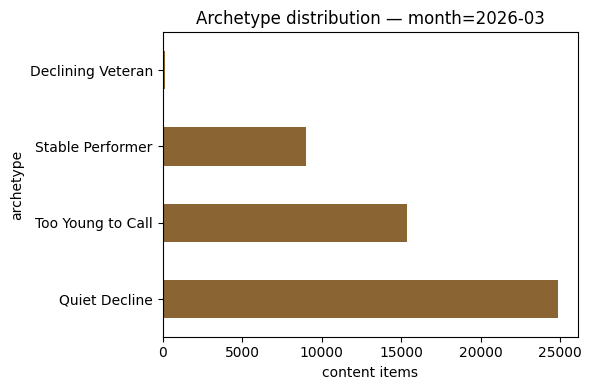

In [12]:
import os
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# --- Queue CSV (not committed, regenerated) ---
queue_cols = ['client_hash_id', 'content_hash_id', 'archetype', 'action', 'reason_code',
              'decline_probability', 'gsc_impressions', 'gsc_avg_position', 'content_age_days',
              'priority_score']
queue[queue_cols].to_csv('work/outputs/content_action_playbook.csv', index=False)
print('written: work/outputs/content_action_playbook.csv')

# --- Metrics JSON (the receipts — committed) ---
metrics = {
    'month': '2026-03',
    'n_scored': int(len(base)),
    'n_clients': int(base['client_hash_id'].nunique()),
    'population_decline_rate': round(float(base['is_declining'].mean()), 3),
    'archetype_counts': base['archetype'].value_counts().to_dict(),
    'grouped_split_precision_at_20': 0.90,   # from ML-09's executed comparison table
    'grouped_split_test_rows': 1213,          # from ML-09
    'note': 'Directional decision-support numbers, single month, small client-group split — see Section 2 limits.',
}
with open('work/figures/playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('written: work/figures/playbook_metrics.json')

# --- Figure: archetype distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
base['archetype'].value_counts().plot(kind='barh', ax=ax, color='#8A6432')
ax.set_xlabel('content items')
ax.set_title('Archetype distribution — month=2026-03')
plt.tight_layout()
plt.savefig('work/figures/archetype_distribution.png', dpi=150)
print('written: work/figures/archetype_distribution.png')


## Self-check

Before you submit, confirm each line honestly:

- [ x] Every section above is filled — markdown thinking AND the code that backs it
- [ x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ x] No client names, URLs, or private queries anywhere
- [ x] My claims use careful words: observed, measured, directional, decision-support
- [ x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.